In [1]:
import os, sys
project_root = os.path.abspath('..').replace('\\', '/')
if project_root not in [p.replace('\\', '/') for p in sys.path]:
    sys.path.append(project_root)

# 05 指标计算模块 (core.metrics)

提供统一的模型评估指标入口。

**数据说明**: 基于 `hscredit_yyp.xlsx`

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from hscredit import init_setting
from hscredit.core import metrics

init_setting()

# 加载数据
_roots = [Path.cwd(), Path.cwd() / 'examples', Path.cwd().parent]
_fp = None
for _r in _roots:
    for _n in ('hscredit_yyp.xlsx', 'hengshucredit_yyp.xlsx'):
        if (_r / _n).is_file():
            _fp = _r / _n
            break
    if _fp is not None:
        break
if _fp is None:
    raise FileNotFoundError('请将 hscredit_yyp.xlsx 放在 examples/')

df = pd.read_excel(_fp)

# 构造目标变量和预测概率
y_true = (df['MOB1'] > 3).astype(int).values

# 使用中智小牛分C3作为预测分数
y_prob = df['中智小牛分C3'].fillna(df['中智小牛分C3'].median()).values
y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())  # 归一化

print(f"样本数: {len(df):,}")
print(f"坏样本率: {y_true.mean():.2%}")

样本数: 970
坏样本率: 16.70%


## 1. 分类指标

In [3]:
print("=== 分类指标 ===")
print(f"KS: {metrics.ks(y_true, y_prob):.4f}")
print(f"AUC: {metrics.auc(y_true, y_prob):.4f}")
print(f"Gini: {metrics.gini(y_true, y_prob):.4f}")

=== 分类指标 ===
KS: 0.1006
AUC: 0.4495
Gini: -0.1010


## 2. 特征评估指标

In [4]:
# IV计算
feature = df['中智小牛分C3'].fillna(df['中智小牛分C3'].median()).values
iv_value = metrics.iv(y_true, feature, n_bins=10)

print(f"IV值: {iv_value:.4f}")

# IV详细表
iv_table = metrics.iv_table(y_true, feature, n_bins=10)
display(iv_table)

IV值: 0.0443


,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"(-inf, 540.45]",49,37,12,0.0505,0.0458,0.0741,0.2449,0.4810,0.0136,0.0443,1.4664,0.0248,1.4664,0.0248,37,12,0.0283
1,1,"(540.45, 584.7]",48,38,10,0.0495,0.0470,0.0617,0.2083,0.2720,0.0040,0.0443,1.2474,0.0129,1.3580,0.0398,75,22,0.0430
2,2,"(584.7, 629.0]",55,47,8,0.0567,0.0582,0.0494,0.1455,-0.1637,0.0014,0.0443,0.8709,-0.0078,1.1818,0.0338,122,30,0.0342
3,3,"(629.0, 727.55]",769,641,128,0.7928,0.7933,0.7901,0.1664,-0.0040,0.0000,0.0443,0.9966,-0.0128,1.0272,0.5112,763,158,0.0310
4,4,"(727.55, +inf]",49,45,4,0.0505,0.0557,0.0247,0.0816,-0.8134,0.0252,0.0443,0.4888,-0.0272,1.0000,0.0000,808,162,0.0000


## 3. 金融风控指标

In [5]:
print("=== Lift指标 ===")
for ratio in [0.01, 0.03, 0.05, 0.10]:
    lift_value = metrics.lift_at(y_true, y_prob, ratios=ratio)
    print(f"Lift@{ratio*100:.0f}%: {lift_value:.2f}")

# Lift曲线
lift_curve = metrics.lift_curve(y_true, y_prob)

plt.figure(figsize=(10, 4))
plt.plot(lift_curve['percentage'] * 100, lift_curve['lift'], 'o-', linewidth=2)
plt.axhline(y=1, color='red', linestyle='--')
plt.xlabel('覆盖率 (%)')
plt.ylabel('Lift值')
plt.title('Lift曲线')
plt.grid(True, alpha=0.3)
plt.show()

=== Lift指标 ===
Lift@1%: 0.00
Lift@3%: 0.41
Lift@5%: 0.37
Lift@10%: 0.62


KeyError: 'percentage'

<Figure size 1000x400 with 0 Axes>

## 4. 批量IV计算

,特征,IV
4,占信V3,0.1627
3,青云24,0.1094
2,极光欺诈分6v1,0.0585
0,中智小牛分C3,0.0443
1,珊瑚92,0.0224


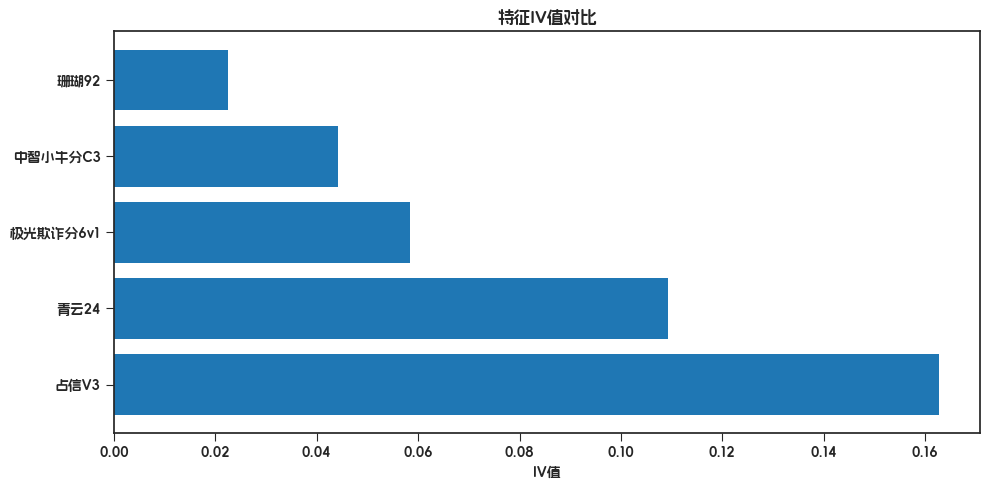

In [6]:
# 批量计算多个特征的IV
features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3']

iv_results = []
for feat_name in features:
    feat_values = df[feat_name].fillna(df[feat_name].median())
    iv_val = metrics.iv(y_true, feat_values, n_bins=10)
    iv_results.append({'特征': feat_name, 'IV': iv_val})

iv_results_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)
display(iv_results_df)

plt.figure(figsize=(10, 5))
plt.barh(iv_results_df['特征'], iv_results_df['IV'])
plt.xlabel('IV值')
plt.title('特征IV值对比')
plt.tight_layout()
plt.show()